In [33]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

from xgboost import XGBClassifier

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [34]:
DATA_PATH = (
    r"C:\Users\Steve\Desktop\datascience-project1"
    r"\project\data\processed\fact_orders.csv"
)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (99441, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_after_carrier_flag,late_delivery_flag,...,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,review_score,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,...,3149,sao paulo,SP,38.71,3.0,"credit_card, voucher",1.0,4.0,NaN,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,...,47813,barreiras,BA,141.46,1.0,boleto,1.0,4.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,...,75265,vianopolis,GO,179.12,1.0,credit_card,3.0,5.0,NaN,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,...,59296,sao goncalo do amarante,RN,72.20,1.0,credit_card,1.0,5.0,NaN,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,...,9195,santo andre,SP,28.62,1.0,credit_card,1.0,5.0,NaN,NaN


In [35]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

df[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object

In [36]:
df["purchase_year"] = (
    df["order_purchase_timestamp"].dt.year
)

df["purchase_month"] = (
    df["order_purchase_timestamp"].dt.month
)

df["purchase_month_name"] = (
    df["order_purchase_timestamp"]
    .dt.month_name()
)

df["purchase_quarter"] = (
    df["order_purchase_timestamp"]
    .dt.quarter
)

df["purchase_day"] = (
    df["order_purchase_timestamp"].dt.day
)

df["purchase_weekday"] = (
    df["order_purchase_timestamp"].dt.day_name()
)

df["purchase_hour"] = (
    df["order_purchase_timestamp"].dt.hour
)

print("Time features created.")

Time features created.


In [37]:
df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"]
    - df["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

df["estimated_delivery_days"] = (
    df["estimated_delivery_days"].round(2)
)

df["estimated_delivery_days"].describe()

count    99441.000000
mean        23.767671
std          8.832380
min          1.650000
25%         18.330000
50%         23.240000
75%         28.420000
max        155.140000
Name: estimated_delivery_days, dtype: float64

In [56]:
df["multiple_payment_methods"] = (
    df["payment_count"] > 1
).astype(int)

df["avg_payment_per_installment"] = (
    df["total_payment"]
    / df["max_installments"].replace(0, np.nan)
)

df["avg_payment_per_installment"] = (
    df["avg_payment_per_installment"]
    .replace([np.inf, -np.inf], np.nan)
)

print("Payment features created.")

Payment features created.


In [57]:
new_features = [
    "purchase_year",
    "purchase_month",
    "purchase_month_name",
    "purchase_quarter",
    "purchase_day",
    "purchase_weekday",
    "purchase_hour",
    "estimated_delivery_days",
    "multiple_payment_methods",
    "avg_payment_per_installment"
]

df[new_features].head()

,purchase_year,purchase_month,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,estimated_delivery_days,multiple_payment_methods,avg_payment_per_installment
0,2017,10,October,4,2,Monday,10,15.54,1,38.710000
1,2018,7,July,3,24,Tuesday,20,19.14,0,141.460000
2,2018,8,August,3,8,Wednesday,8,26.64,0,59.706667
3,2017,11,November,4,18,Saturday,19,26.19,0,72.200000
4,2018,2,February,1,13,Tuesday,21,12.11,0,28.620000


In [58]:
print("Target counts:")
print(df["late_delivery_flag"].value_counts())

print("\nTarget percentage:")
print(
    df["late_delivery_flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target counts:
late_delivery_flag
False    91614
True      7827
Name: count, dtype: int64

Target percentage:
late_delivery_flag
False    92.13
True      7.87
Name: proportion, dtype: float64


In [59]:
FEATURES = [
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",

    "total_payment",
    "payment_count",
    "payment_type",
    "max_installments",
    "avg_payment_per_installment",
    "multiple_payment_methods",

    "purchase_year",
    "purchase_month",
    "purchase_month_name",
    "purchase_quarter",
    "purchase_day",
    "purchase_weekday",
    "purchase_hour",

    "estimated_delivery_days"
]

TARGET = "late_delivery_flag"

X = df[FEATURES].copy()
y = df[TARGET].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for feature in FEATURES:
    print("-", feature)

X shape: (99441, 17)
y shape: (99441,)

Features:
- customer_zip_code_prefix
- customer_city
- customer_state
- total_payment
- payment_count
- payment_type
- max_installments
- avg_payment_per_installment
- multiple_payment_methods
- purchase_year
- purchase_month
- purchase_month_name
- purchase_quarter
- purchase_day
- purchase_weekday
- purchase_hour
- estimated_delivery_days


In [60]:
FORBIDDEN_FEATURES = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "approval_after_carrier_flag",
    "delivery_before_carrier_flag",
    "late_delivery_flag"
]

leakage_found = [
    col
    for col in FORBIDDEN_FEATURES
    if col in X.columns
]

print(
    "Forbidden features found in X:",
    leakage_found
)

assert len(leakage_found) == 0, (
    f"Potential leakage detected: {leakage_found}"
)

print("✓ Leakage audit passed.")

Forbidden features found in X: []
✓ Leakage audit passed.


In [61]:
missing = (
    X.isna()
    .sum()
    .sort_values(ascending=False)
)

print("Missing values:")
print(missing[missing > 0])

Missing values:
avg_payment_per_installment    3
max_installments               1
payment_count                  1
payment_type                   1
total_payment                  1
dtype: int64


In [62]:
numeric_features = [
    "customer_zip_code_prefix",
    "total_payment",
    "payment_count",
    "max_installments",
    "avg_payment_per_installment",
    "purchase_year",
    "purchase_month",
    "purchase_quarter",
    "purchase_day",
    "purchase_hour",
    "estimated_delivery_days"
]

categorical_features = [
    "customer_city",
    "customer_state",
    "payment_type",
    "purchase_month_name",
    "purchase_weekday"
]

boolean_features = [
    "multiple_payment_methods"
]

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))
print("Boolean:", len(boolean_features))

Numeric: 11
Categorical: 5
Boolean: 1


In [63]:
all_pipeline_features = (
    numeric_features
    + categorical_features
    + boolean_features
)

missing_from_pipeline = sorted(
    set(FEATURES)
    - set(all_pipeline_features)
)

unexpected_features = sorted(
    set(all_pipeline_features)
    - set(FEATURES)
)

print(
    "Missing from pipeline:",
    missing_from_pipeline
)

print(
    "Unexpected features:",
    unexpected_features
)

assert not missing_from_pipeline
assert not unexpected_features

print("✓ All features accounted for.")

Missing from pipeline: []
Unexpected features: []
✓ All features accounted for.


In [64]:
TEST_SIZE = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining target distribution:")
print(
    y_train
    .value_counts(normalize=True)
    .round(4)
)

print("\nTesting target distribution:")
print(
    y_test
    .value_counts(normalize=True)
    .round(4)
)

Training shape: (79552, 17)
Testing shape : (19889, 17)

Training target distribution:
late_delivery_flag
0    0.9213
1    0.0787
Name: proportion, dtype: float64

Testing target distribution:
late_delivery_flag
0    0.9213
1    0.0787
Name: proportion, dtype: float64


In [65]:
print("Train rows:", len(X_train))
print("Test rows :", len(X_test))

overlap = X_train.index.intersection(
    X_test.index
)

print("Overlapping rows:", len(overlap))

assert len(overlap) == 0

print("✓ No train/test row overlap.")

Train rows: 79552
Test rows : 19889
Overlapping rows: 0
✓ No train/test row overlap.


In [66]:
distribution = pd.DataFrame({
    "Train": y_train.value_counts(
        normalize=True
    ),
    "Test": y_test.value_counts(
        normalize=True
    )
})

distribution.index = [
    "On Time",
    "Late"
]

distribution.round(4)

,Train,Test
On Time,0.9213,0.9213
Late,0.0787,0.0787


In [67]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

In [68]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])

In [69]:
boolean_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    )
])

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        ),
        (
            "bool",
            boolean_pipeline,
            boolean_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [71]:
xgb_v1 = XGBClassifier(
    subsample=0.7,
    n_estimators=500,
    min_child_weight=3,
    max_depth=7,
    learning_rate=0.2,
    colsample_bytree=0.6,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)

print("XGBoost V1 defined.")

XGBoost V1 defined.


In [72]:
xgb_pipeline_v1 = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        xgb_v1
    )
])

print("XGBoost V1 pipeline created.")

XGBoost V1 pipeline created.


In [73]:
print("Training XGBoost V1...")

xgb_pipeline_v1.fit(
    X_train,
    y_train
)

print("Training complete.")

Training XGBoost V1...
Training complete.


In [74]:
y_pred_v1 = xgb_pipeline_v1.predict(X_test)

y_prob_v1 = xgb_pipeline_v1.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [75]:
v1_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_v1),
    "Precision": precision_score(
        y_test, y_pred_v1, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred_v1, zero_division=0
    ),
    "F1": f1_score(
        y_test, y_pred_v1, zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test, y_prob_v1
    ),
    "PR AUC": average_precision_score(
        y_test, y_prob_v1
    )
}

v1_results = pd.DataFrame([v1_metrics]).round(4)

v1_results

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,0.9192,0.4545,0.1342,0.2072,0.7813,0.2739


In [76]:
print(
    classification_report(
        y_test,
        y_pred_v1,
        target_names=["On Time", "Late"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     On Time       0.93      0.99      0.96     18324
        Late       0.45      0.13      0.21      1565

    accuracy                           0.92     19889
   macro avg       0.69      0.56      0.58     19889
weighted avg       0.89      0.92      0.90     19889



In [77]:
cm_v1 = confusion_matrix(
    y_test,
    y_pred_v1
)

print("Confusion Matrix:")
print(cm_v1)

Confusion Matrix:
[[18072   252]
 [ 1355   210]]


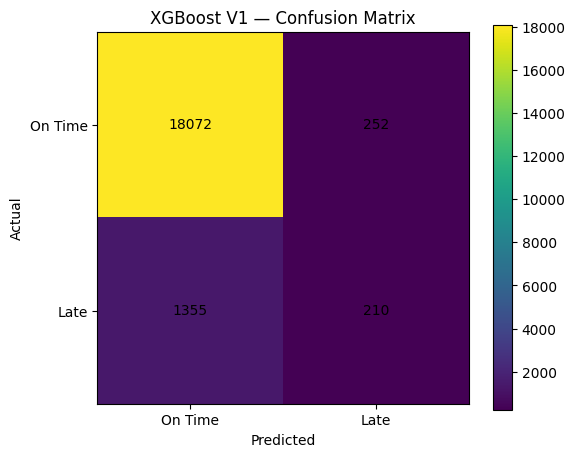

In [78]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_v1)

plt.title("XGBoost V1 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["On Time", "Late"])
plt.yticks([0, 1], ["On Time", "Late"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_v1[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [79]:
baseline_results = pd.DataFrame({
    "Metric": list(v1_metrics.keys()),
    "V1": list(v1_metrics.values())
})

baseline_results.round(4)

,Metric,V1
0,Accuracy,0.9192
1,Precision,0.4545
2,Recall,0.1342
3,F1,0.2072
4,ROC AUC,0.7813
5,PR AUC,0.2739


In [83]:
thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_v1 >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Predicted Late": y_pred_threshold.sum()
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,Threshold,Precision,Recall,F1,Predicted Late
0,0.10,0.2284,0.5732,0.3267,3927
1,0.15,0.2685,0.4601,0.3391,2682
2,0.20,0.3090,0.3898,0.3447,1974
3,0.25,0.3360,0.3208,0.3282,1494
4,0.30,0.3723,0.2709,0.3136,1139
5,0.35,0.3872,0.2249,0.2846,909
6,0.40,0.4118,0.1923,0.2622,731
7,0.45,0.4293,0.1572,0.2301,573
8,0.50,0.4545,0.1342,0.2072,462
9,0.55,0.4699,0.0997,0.1645,332


In [85]:

#Cell 31 — Find the best F1 threshold
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold_row)

Best threshold based on F1:
Threshold            0.200000
Precision            0.309017
Recall               0.389776
F1                   0.344730
Predicted Late    1974.000000
Name: 2, dtype: float64


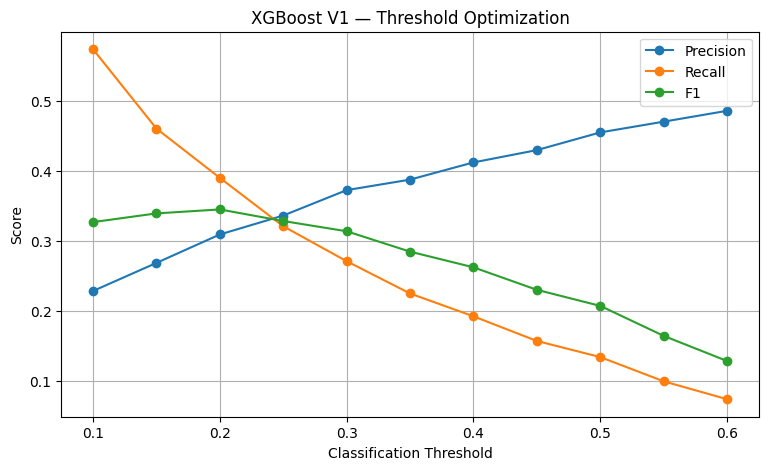

In [86]:

#Cell 32 — Visualize the trade-off
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost V1 — Threshold Optimization")
plt.legend()
plt.grid(True)
plt.show()

In [87]:

#Cell 33 — Evaluate the selected threshold
best_threshold = best_threshold_row["Threshold"]

y_pred_v2 = (
    y_prob_v1 >= best_threshold
).astype(int)

print("Selected threshold:", best_threshold)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_v2,
        target_names=["On Time", "Late"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_v2
    )
)

Selected threshold: 0.20000000000000004

Classification Report:
              precision    recall  f1-score   support

     On Time       0.95      0.93      0.94     18324
        Late       0.31      0.39      0.34      1565

    accuracy                           0.88     19889
   macro avg       0.63      0.66      0.64     19889
weighted avg       0.90      0.88      0.89     19889


Confusion Matrix:
[[16960  1364]
 [  955   610]]


In [88]:

#Cell 34 — Compare V1 vs threshold-adjusted model
comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC"
    ],

    "Default Threshold (0.50)": [
        precision_score(y_test, y_pred_v1, zero_division=0),
        recall_score(y_test, y_pred_v1, zero_division=0),
        f1_score(y_test, y_pred_v1, zero_division=0),
        roc_auc_score(y_test, y_prob_v1),
        average_precision_score(y_test, y_prob_v1)
    ],

    f"Optimized Threshold ({best_threshold:.2f})": [
        precision_score(y_test, y_pred_v2, zero_division=0),
        recall_score(y_test, y_pred_v2, zero_division=0),
        f1_score(y_test, y_pred_v2, zero_division=0),
        roc_auc_score(y_test, y_prob_v1),
        average_precision_score(y_test, y_prob_v1)
    ]
})

comparison.round(4)

,Metric,Default Threshold (0.50),Optimized Threshold (0.20)
0,Precision,0.4545,0.3090
1,Recall,0.1342,0.3898
2,F1,0.2072,0.3447
3,ROC AUC,0.7813,0.7813
4,PR AUC,0.2739,0.2739


In [89]:
thresholds = np.arange(0.05, 0.51, 0.01)

FN_COST = 3
FP_COST = 1

cost_results = []

for threshold in thresholds:

    predictions = (
        y_prob_v1 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    total_cost = (
        FN_COST * fn +
        FP_COST * fp
    )

    cost_results.append({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Total Cost": total_cost
    })

cost_results = pd.DataFrame(cost_results)

cost_results.round(4)

,Threshold,TP,FP,FN,TN,Precision,Recall,F1,Total Cost
0,0.05,1129,5456,436,12868,0.1715,0.7214,0.2771,6764
1,0.06,1068,4732,497,13592,0.1841,0.6824,0.2900,6223
2,0.07,1018,4168,547,14156,0.1963,0.6505,0.3016,5809
3,0.08,972,3723,593,14601,0.2070,0.6211,0.3105,5502
4,0.09,929,3353,636,14971,0.2170,0.5936,0.3178,5261
5,0.10,897,3030,668,15294,0.2284,0.5732,0.3267,5034
6,0.11,854,2761,711,15563,0.2362,0.5457,0.3297,4894
7,0.12,817,2522,748,15802,0.2447,0.5220,0.3332,4766
8,0.13,780,2314,785,16010,0.2521,0.4984,0.3348,4669
9,0.14,757,2131,808,16193,0.2621,0.4837,0.3400,4555


In [90]:
best_cost_row = cost_results.loc[
    cost_results["Total Cost"].idxmin()
]

print("Best threshold based on cost:")
print(best_cost_row)

Best threshold based on cost:
Threshold         0.290000
TP              440.000000
FP              752.000000
FN             1125.000000
TN            17572.000000
Precision         0.369128
Recall            0.281150
F1                0.319188
Total Cost     4127.000000
Name: 24, dtype: float64


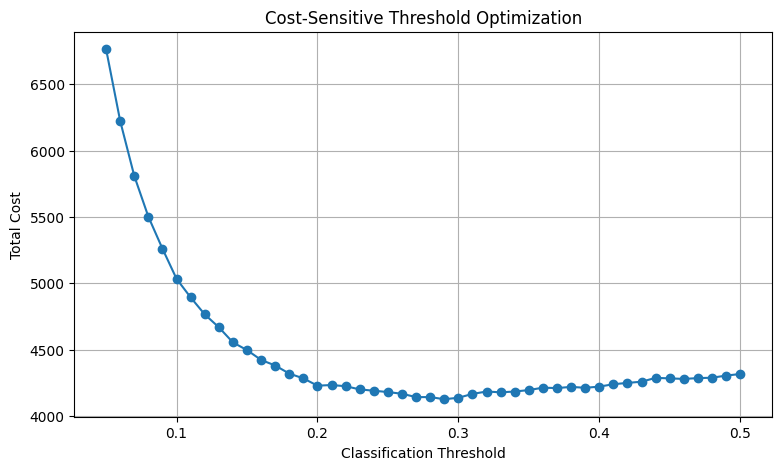

In [91]:
plt.figure(figsize=(9, 5))

plt.plot(
    cost_results["Threshold"],
    cost_results["Total Cost"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Total Cost")
plt.title("Cost-Sensitive Threshold Optimization")

plt.grid(True)
plt.show()

In [92]:
print("F1-optimal threshold:")
print(best_threshold_row)

print("\nCost-optimal threshold:")
print(best_cost_row)

F1-optimal threshold:
Threshold            0.200000
Precision            0.309017
Recall               0.389776
F1                   0.344730
Predicted Late    1974.000000
Name: 2, dtype: float64

Cost-optimal threshold:
Threshold         0.290000
TP              440.000000
FP              752.000000
FN             1125.000000
TN            17572.000000
Precision         0.369128
Recall            0.281150
F1                0.319188
Total Cost     4127.000000
Name: 24, dtype: float64


In [93]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("Scale Pos Weight:", round(scale_pos_weight, 4))

Negative samples: 73290
Positive samples: 6262
Scale Pos Weight: 11.7039


In [94]:
xgb_pipeline_v2 = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.2,
        min_child_weight=3,
        subsample=0.7,
        colsample_bytree=0.6,

        scale_pos_weight=scale_pos_weight,

        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

print("V2 pipeline created.")

V2 pipeline created.


In [95]:
print("Training XGBoost V2...")

xgb_pipeline_v2.fit(
    X_train,
    y_train
)

print("✓ V2 training complete.")

Training XGBoost V2...
✓ V2 training complete.


In [96]:
y_pred_v2_default = xgb_pipeline_v2.predict(X_test)

y_prob_v2 = (
    xgb_pipeline_v2
    .predict_proba(X_test)[:, 1]
)

print("Predictions generated.")

Predictions generated.


In [97]:
v2_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_v2_default
    ),

    "Precision": precision_score(
        y_test,
        y_pred_v2_default,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred_v2_default,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        y_pred_v2_default,
        zero_division=0
    ),

    "ROC AUC": roc_auc_score(
        y_test,
        y_prob_v2
    ),

    "PR AUC": average_precision_score(
        y_test,
        y_prob_v2
    )
}

pd.DataFrame([v2_metrics]).round(4)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,0.8313,0.2362,0.5125,0.3234,0.7769,0.2858


In [98]:
model_comparison = pd.DataFrame([
    {
        "Model": "XGBoost V1",
        **v1_metrics
    },
    {
        "Model": "XGBoost V2 - Class Weighted",
        **v2_metrics
    }
])

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,XGBoost V1,0.9192,0.4545,0.1342,0.2072,0.7813,0.2739
1,XGBoost V2 - Class Weighted,0.8313,0.2362,0.5125,0.3234,0.7769,0.2858


[[15731  2593]
 [  763   802]]


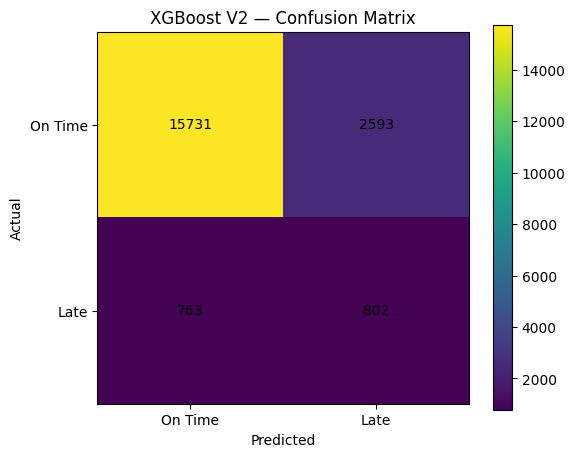

In [99]:
cm_v2 = confusion_matrix(
    y_test,
    y_pred_v2_default
)

print(cm_v2)

plt.figure(figsize=(6, 5))

plt.imshow(cm_v2)

plt.title("XGBoost V2 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["On Time", "Late"]
)

plt.yticks(
    [0, 1],
    ["On Time", "Late"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_v2[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [100]:
print(
    classification_report(
        y_test,
        y_pred_v2_default,
        target_names=[
            "On Time",
            "Late"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     On Time       0.95      0.86      0.90     18324
        Late       0.24      0.51      0.32      1565

    accuracy                           0.83     19889
   macro avg       0.59      0.69      0.61     19889
weighted avg       0.90      0.83      0.86     19889



In [101]:
thresholds_v2 = np.arange(0.10, 0.71, 0.05)

threshold_results_v2 = []

for threshold in thresholds_v2:

    predictions = (
        y_prob_v2 >= threshold
    ).astype(int)

    threshold_results_v2.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Predicted Late": predictions.sum()
    })

threshold_results_v2 = pd.DataFrame(
    threshold_results_v2
)

threshold_results_v2.round(4)

,Threshold,Precision,Recall,F1,Predicted Late
0,0.10,0.1150,0.8952,0.2038,12185
1,0.15,0.1306,0.8339,0.2259,9989
2,0.20,0.1456,0.7808,0.2455,8392
3,0.25,0.1617,0.7399,0.2654,7163
4,0.30,0.1780,0.7042,0.2842,6190
5,0.35,0.1912,0.6518,0.2957,5334
6,0.40,0.2056,0.6070,0.3071,4621
7,0.45,0.2194,0.5604,0.3154,3997
8,0.50,0.2362,0.5125,0.3234,3395
9,0.55,0.2578,0.4767,0.3346,2894


In [102]:
best_threshold_v2 = threshold_results_v2.loc[
    threshold_results_v2["F1"].idxmax()
]

print("V2 best threshold:")
print(best_threshold_v2)

V2 best threshold:
Threshold            0.650000
Precision            0.305882
Recall               0.398722
F1                   0.346186
Predicted Late    2040.000000
Name: 11, dtype: float64


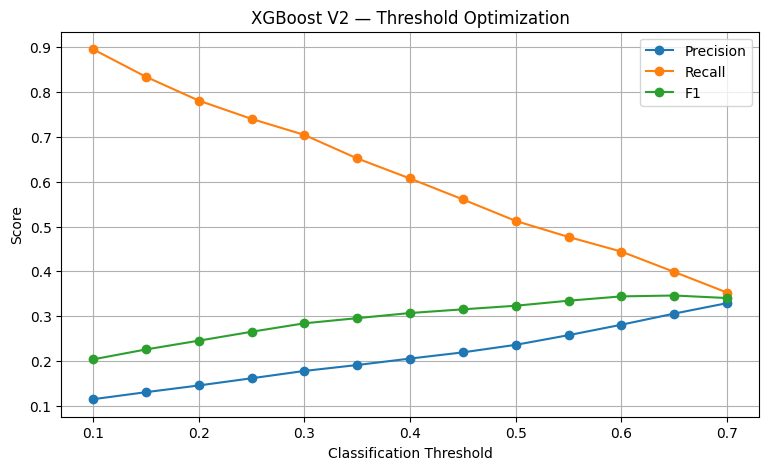

In [103]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_v2["Threshold"],
    threshold_results_v2["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_v2["Threshold"],
    threshold_results_v2["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_v2["Threshold"],
    threshold_results_v2["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost V2 — Threshold Optimization")

plt.legend()
plt.grid(True)

plt.show()

In [104]:
optimal_threshold_v2 = (
    best_threshold_v2["Threshold"]
)

y_pred_v2_optimal = (
    y_prob_v2 >= optimal_threshold_v2
).astype(int)

print(
    "Selected threshold:",
    optimal_threshold_v2
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_v2_optimal,
        target_names=[
            "On Time",
            "Late"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_v2_optimal
    )
)

Selected threshold: 0.6500000000000001

Classification Report:
              precision    recall  f1-score   support

     On Time       0.95      0.92      0.93     18324
        Late       0.31      0.40      0.35      1565

    accuracy                           0.88     19889
   macro avg       0.63      0.66      0.64     19889
weighted avg       0.90      0.88      0.89     19889


Confusion Matrix:
[[16908  1416]
 [  941   624]]


In [105]:
final_comparison = pd.DataFrame([
    {
        "Model": "V1 — Default 0.50",
        "Threshold": 0.50,
        "Precision": precision_score(
            y_test,
            y_pred_v1,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_v1,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_v1,
            zero_division=0
        ),
        "PR AUC": average_precision_score(
            y_test,
            y_prob_v1
        )
    },

    {
        "Model": "V1 — F1 Optimal",
        "Threshold": best_threshold_row["Threshold"],
        "Precision": best_threshold_row["Precision"],
        "Recall": best_threshold_row["Recall"],
        "F1": best_threshold_row["F1"],
        "PR AUC": average_precision_score(
            y_test,
            y_prob_v1
        )
    },

    {
        "Model": "V2 — Default 0.50",
        "Threshold": 0.50,
        "Precision": precision_score(
            y_test,
            y_pred_v2_default,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_v2_default,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_v2_default,
            zero_division=0
        ),
        "PR AUC": average_precision_score(
            y_test,
            y_prob_v2
        )
    },

    {
        "Model": "V2 — F1 Optimal",
        "Threshold": optimal_threshold_v2,
        "Precision": precision_score(
            y_test,
            y_pred_v2_optimal,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_v2_optimal,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_v2_optimal,
            zero_division=0
        ),
        "PR AUC": average_precision_score(
            y_test,
            y_prob_v2
        )
    }
])

final_comparison.round(4)

,Model,Threshold,Precision,Recall,F1,PR AUC
0,V1 — Default 0.50,0.50,0.4545,0.1342,0.2072,0.2739
1,V1 — F1 Optimal,0.20,0.3090,0.3898,0.3447,0.2739
2,V2 — Default 0.50,0.50,0.2362,0.5125,0.3234,0.2858
3,V2 — F1 Optimal,0.65,0.3059,0.3987,0.3462,0.2858


In [106]:
V2_THRESHOLD = 0.65

v2_final_predictions = (
    y_prob_v2 >= V2_THRESHOLD
).astype(int)

v2_final_metrics = {
    "Model": "XGBoost V2",
    "Threshold": V2_THRESHOLD,
    "Accuracy": accuracy_score(
        y_test,
        v2_final_predictions
    ),
    "Precision": precision_score(
        y_test,
        v2_final_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        v2_final_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        v2_final_predictions,
        zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        y_prob_v2
    ),
    "PR AUC": average_precision_score(
        y_test,
        y_prob_v2
    )
}

pd.DataFrame([v2_final_metrics])

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,XGBoost V2,0.65,0.881492,0.305882,0.398722,0.346186,0.776901,0.285822


In [107]:
cm_v2_final = confusion_matrix(
    y_test,
    v2_final_predictions
)

print("V2 Final Confusion Matrix")
print(cm_v2_final)

tn, fp, fn, tp = cm_v2_final.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nLate detection rate:", tp / (tp + fn))
print("False negative rate:", fn / (tp + fn))

V2 Final Confusion Matrix
[[16908  1416]
 [  941   624]]

TN: 16908
FP: 1416
FN: 941
TP: 624

Late detection rate: 0.3987220447284345
False negative rate: 0.6012779552715655


In [108]:
model_comparison = pd.DataFrame([
    {
        "Model": "V1",
        "Threshold": 0.20,
        "Precision": 0.3090,
        "Recall": 0.3898,
        "F1": 0.3447,
        "PR AUC": 0.2739
    },
    {
        "Model": "V2",
        "Threshold": 0.65,
        "Precision": 0.3059,
        "Recall": 0.3987,
        "F1": 0.3462,
        "PR AUC": 0.2858
    }
])

model_comparison

,Model,Threshold,Precision,Recall,F1,PR AUC
0,V1,0.20,0.3090,0.3898,0.3447,0.2739
1,V2,0.65,0.3059,0.3987,0.3462,0.2858


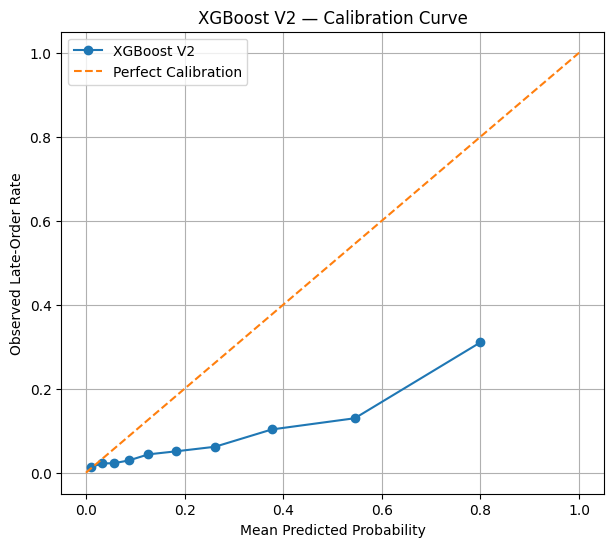

In [109]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_v2,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost V2"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Late-Order Rate")

plt.title("XGBoost V2 — Calibration Curve")

plt.legend()
plt.grid(True)

plt.show()

In [110]:
calibration_df = pd.DataFrame({
    "actual": y_test.values,
    "probability": y_prob_v2
})

calibration_df["probability_bucket"] = pd.qcut(
    calibration_df["probability"],
    q=10,
    duplicates="drop"
)

calibration_summary = (
    calibration_df
    .groupby("probability_bucket", observed=True)
    .agg(
        predicted_probability=("probability", "mean"),
        actual_late_rate=("actual", "mean"),
        samples=("actual", "size")
    )
    .reset_index()
)

calibration_summary

,probability_bucket,predicted_probability,actual_late_rate,samples
0,"(-0.000999594, 0.0213]",0.010838,0.013575,1989
1,"(0.0213, 0.0437]",0.032477,0.022122,1989
2,"(0.0437, 0.0701]",0.056413,0.022624,1989
3,"(0.0701, 0.105]",0.086826,0.029160,1989
4,"(0.105, 0.151]",0.126725,0.043741,1989
5,"(0.151, 0.217]",0.181710,0.050805,1988
6,"(0.217, 0.312]",0.261748,0.061840,1989
7,"(0.312, 0.451]",0.377022,0.103067,1989
8,"(0.451, 0.656]",0.545195,0.129713,1989
9,"(0.656, 0.994]",0.799646,0.310206,1989


In [111]:
from sklearn.calibration import CalibratedClassifierCV

print("Starting probability calibration...")

calibrated_v2 = CalibratedClassifierCV(
    
    estimator=xgb_pipeline_v2,
    method="sigmoid",
    cv=5
)

calibrated_v2.fit(
    X_train,
    y_train
)

print("✓ Calibration complete.")

Starting probability calibration...
✓ Calibration complete.


In [112]:
y_prob_v2_calibrated = calibrated_v2.predict_proba(
    X_test
)[:, 1]

print("Calibrated probability range:")
print(
    y_prob_v2_calibrated.min(),
    y_prob_v2_calibrated.max()
)

Calibrated probability range:
0.025452974148553586 0.47542326800322554


In [113]:
y_pred_calibrated_05 = (
    y_prob_v2_calibrated >= 0.50
).astype(int)

calibrated_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_calibrated_05
    ),
    "Precision": precision_score(
        y_test,
        y_pred_calibrated_05,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_calibrated_05,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_pred_calibrated_05,
        zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        y_prob_v2_calibrated
    ),
    "PR AUC": average_precision_score(
        y_test,
        y_prob_v2_calibrated
    )
}

pd.DataFrame([calibrated_metrics])

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,0.921313,0.0,0.0,0.0,0.792931,0.310189


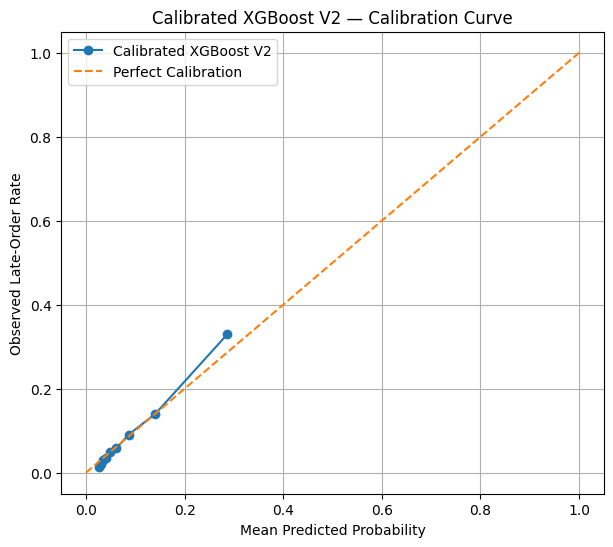

In [114]:
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    y_prob_v2_calibrated,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Calibrated XGBoost V2"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Late-Order Rate")

plt.title("Calibrated XGBoost V2 — Calibration Curve")

plt.legend()
plt.grid(True)

plt.show()

In [115]:
calibration_df = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob_v2_calibrated
})

calibration_df["Probability_Bucket"] = pd.qcut(
    calibration_df["Probability"],
    q=10,
    duplicates="drop"
)

calibration_summary = (
    calibration_df
    .groupby(
        "Probability_Bucket",
        observed=True
    )
    .agg(
        Mean_Predicted_Probability=(
            "Probability",
            "mean"
        ),
        Actual_Late_Rate=(
            "Actual",
            "mean"
        ),
        Samples=(
            "Actual",
            "size"
        )
    )
    .reset_index()
)

calibration_summary

,Probability_Bucket,Mean_Predicted_Probability,Actual_Late_Rate,Samples
0,"(0.024499999999999997, 0.0277]",0.026598,0.013575,1989
1,"(0.0277, 0.0299]",0.028785,0.018602,1989
2,"(0.0299, 0.0329]",0.031343,0.020111,1989
3,"(0.0329, 0.0371]",0.034885,0.030669,1989
4,"(0.0371, 0.0433]",0.040002,0.035696,1989
5,"(0.0433, 0.0535]",0.048018,0.049296,1988
6,"(0.0535, 0.0713]",0.061362,0.057818,1989
7,"(0.0713, 0.107]",0.086865,0.091001,1989
8,"(0.107, 0.19]",0.140685,0.140271,1989
9,"(0.19, 0.475]",0.286823,0.329814,1989


In [116]:
threshold_results_calibrated = []

thresholds = np.arange(
    0.05,
    0.71,
    0.01
)

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_v2_calibrated >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results_calibrated.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Predicted_Late": y_pred_threshold.sum()
    })

calibrated_threshold_df = pd.DataFrame(
    threshold_results_calibrated
)

calibrated_threshold_df

,Threshold,Precision,Recall,F1,Predicted_Late
0,0.05,0.148764,0.811502,0.251435,8537
1,0.06,0.167919,0.756550,0.274838,7051
2,0.07,0.185356,0.718211,0.294665,6064
3,0.08,0.199663,0.681789,0.308872,5344
4,0.09,0.212198,0.644728,0.319304,4755
...,...,...,...,...,...
61,0.66,0.000000,0.000000,0.000000,0
62,0.67,0.000000,0.000000,0.000000,0
63,0.68,0.000000,0.000000,0.000000,0
64,0.69,0.000000,0.000000,0.000000,0


NameError: name 'best_calibrated_threshold' is not defined

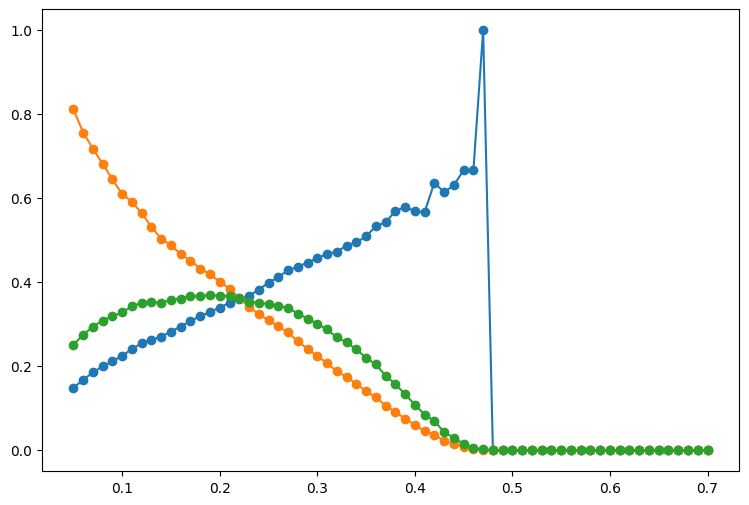

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    calibrated_threshold_df["Threshold"],
    calibrated_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    calibrated_threshold_df["Threshold"],
    calibrated_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    calibrated_threshold_df["Threshold"],
    calibrated_threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.axvline(
    best_calibrated_threshold["Threshold"],
    linestyle="--",
    label="Best F1 Threshold"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Calibrated XGBoost V2 — Threshold Optimization"
)

plt.legend()

plt.grid(True)

plt.show()

In [118]:
# Cell 65 — Select best calibrated threshold

best_calibrated_threshold = (
    calibrated_threshold_df
    .loc[calibrated_threshold_df["F1"].idxmax()]
)

print("Best calibrated threshold:")
print(best_calibrated_threshold)

Best calibrated threshold:
Threshold            0.190000
Precision            0.329317
Recall               0.419169
F1                   0.368850
Predicted_Late    1992.000000
Name: 14, dtype: float64


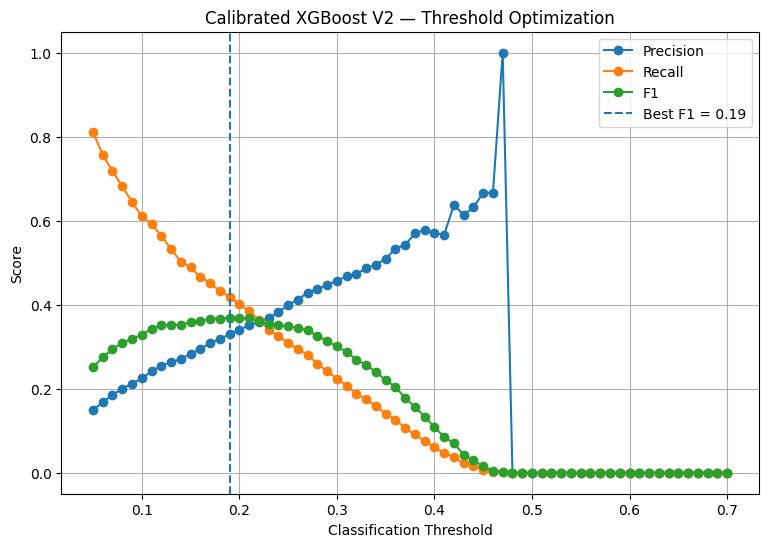

In [119]:
# Cell 66 — Calibrated threshold optimization

plt.figure(figsize=(9, 6))

plt.plot(
    calibrated_threshold_df["Threshold"],
    calibrated_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    calibrated_threshold_df["Threshold"],
    calibrated_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    calibrated_threshold_df["Threshold"],
    calibrated_threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.axvline(
    best_calibrated_threshold["Threshold"],
    linestyle="--",
    label=f"Best F1 = {best_calibrated_threshold['Threshold']:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Calibrated XGBoost V2 — Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [124]:
# Cell 67 — Final calibrated predictions

FINAL_THRESHOLD = float(
    best_calibrated_threshold["Threshold"]
)

y_pred_final = (
    y_prob_v2_calibrated >= FINAL_THRESHOLD
).astype(int)

print("Final threshold:", FINAL_THRESHOLD)
print("Predicted late orders:", y_pred_final.sum())
print("Actual late orders:", y_test.sum())

Final threshold: 0.19
Predicted late orders: 1992
Actual late orders: 1565


In [125]:
# Cell 68 — Final model evaluation

final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    y_prob_v2_calibrated
)

final_pr_auc = average_precision_score(
    y_test,
    y_prob_v2_calibrated
)

final_metrics = pd.DataFrame([{
    "Model": "Calibrated XGBoost V2",
    "Threshold": FINAL_THRESHOLD,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "ROC AUC": final_roc_auc,
    "PR AUC": final_pr_auc
}])

final_metrics

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Calibrated XGBoost V2,0.19,0.887124,0.329317,0.419169,0.36885,0.792931,0.310189


In [128]:
# Cell 69 — Final confusion matrix

cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

print("Final Confusion Matrix:")
print(cm_final)

tn, fp, fn, tp = cm_final.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print(
    "\nLate detection rate:",
    tp / (tp + fn)
)

print(
    "False negative rate:",
    fn / (tp + fn)
)

Final Confusion Matrix:
[[16988  1336]
 [  909   656]]

TN: 16988
FP: 1336
FN: 909
TP: 656

Late detection rate: 0.4191693290734824
False negative rate: 0.5808306709265175


In [129]:
# Cell 70 — Classification report

print(
    classification_report(
        y_test,
        y_pred_final,
        
        target_names=["On Time", "Late"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     On Time       0.95      0.93      0.94     18324
        Late       0.33      0.42      0.37      1565

    accuracy                           0.89     19889
   macro avg       0.64      0.67      0.65     19889
weighted avg       0.90      0.89      0.89     19889



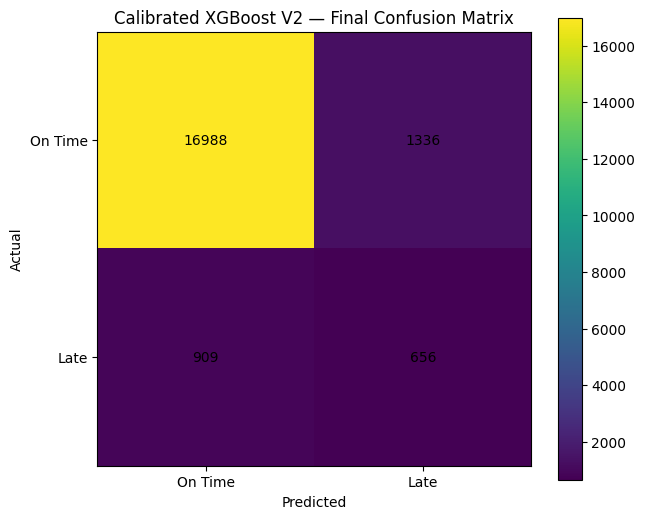

In [130]:
# Cell 71 — Final confusion matrix visualization

plt.figure(figsize=(7, 6))

plt.imshow(
    cm_final,
    interpolation="nearest"
)

plt.title("Calibrated XGBoost V2 — Final Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["On Time", "Late"]
)

plt.yticks(
    [0, 1],
    ["On Time", "Late"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_final[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [131]:
# Cell 72 — Final model comparison

model_comparison = pd.DataFrame([
    {
        "Model": "XGBoost V1 — Default",
        "Threshold": 0.50,
        "Accuracy": 0.9192,
        "Precision": 0.4545,
        "Recall": 0.1342,
        "F1": 0.2072,
        "ROC AUC": 0.7813,
        "PR AUC": 0.2739
    },
    {
        "Model": "XGBoost V1 — F1 Optimized",
        "Threshold": 0.20,
        "Accuracy": 0.88,
        "Precision": 0.3090,
        "Recall": 0.3898,
        "F1": 0.3447,
        "ROC AUC": 0.7813,
        "PR AUC": 0.2739
    },
    {
        "Model": "XGBoost V2 — Class Weighted",
        "Threshold": 0.50,
        "Accuracy": 0.8313,
        "Precision": 0.2362,
        "Recall": 0.5125,
        "F1": 0.3234,
        "ROC AUC": 0.7769,
        "PR AUC": 0.2858
    },
    {
        "Model": "XGBoost V2 — F1 Optimized",
        "Threshold": 0.65,
        "Accuracy": 0.8815,
        "Precision": 0.3059,
        "Recall": 0.3987,
        "F1": 0.3462,
        "ROC AUC": 0.7769,
        "PR AUC": 0.2858
    },
    {
        "Model": "Calibrated XGBoost V2 — Final",
        "Threshold": FINAL_THRESHOLD,
        "Accuracy": final_accuracy,
        "Precision": final_precision,
        "Recall": final_recall,
        "F1": final_f1,
        "ROC AUC": final_roc_auc,
        "PR AUC": final_pr_auc
    }
])

model_comparison.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,XGBoost V1 — Default,0.50,0.9192,0.4545,0.1342,0.2072,0.7813,0.2739
1,XGBoost V1 — F1 Optimized,0.20,0.8800,0.3090,0.3898,0.3447,0.7813,0.2739
2,XGBoost V2 — Class Weighted,0.50,0.8313,0.2362,0.5125,0.3234,0.7769,0.2858
3,XGBoost V2 — F1 Optimized,0.65,0.8815,0.3059,0.3987,0.3462,0.7769,0.2858
4,Calibrated XGBoost V2 — Final,0.19,0.8871,0.3293,0.4192,0.3689,0.7929,0.3102


In [132]:
# Cell 73 — Save final calibrated model

MODEL_DIR = r"C:\Users\Steve\Desktop\datascience-project1\project\models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

model_path = os.path.join(
    MODEL_DIR,
    "xgboost_v2_calibrated.joblib"
)

joblib.dump(
    calibrated_v2,
    model_path
)

threshold_path = os.path.join(
    MODEL_DIR,
    "final_threshold.joblib"
)

joblib.dump(
    FINAL_THRESHOLD,
    threshold_path
)

print("✓ Final model saved:")
print(model_path)

print("\n✓ Final threshold saved:")
print(threshold_path)

✓ Final model saved:
C:\Users\Steve\Desktop\datascience-project1\project\models\xgboost_v2_calibrated.joblib

✓ Final threshold saved:
C:\Users\Steve\Desktop\datascience-project1\project\models\final_threshold.joblib


In [133]:
MODEL_DIR = r"C:\Users\Steve\Desktop\datascience-project1\project\models"

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(
    calibrated_v2,
    os.path.join(
        MODEL_DIR,
        "late_delivery_xgboost_calibrated_v2.joblib"
    )
)

joblib.dump(
    FINAL_THRESHOLD,
    os.path.join(
        MODEL_DIR,
        "late_delivery_threshold.joblib"
    )
)

print("Model and threshold saved successfully.")

Model and threshold saved successfully.


In [134]:
feature_config = {
    "features": FEATURES,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "boolean_features": boolean_features,
    "target": TARGET,
    "threshold": FINAL_THRESHOLD
}

joblib.dump(
    feature_config,
    os.path.join(
        MODEL_DIR,
        "late_delivery_feature_config.joblib"
    )
)

print("Feature configuration saved.")

Feature configuration saved.


In [135]:
def predict_late_delivery(order_data):
    """
    Predict whether an order is likely to be delivered late.

    Returns:
        prediction: 0 = on time, 1 = likely late
        probability: calibrated probability of late delivery
    """

    input_df = pd.DataFrame([order_data])

    probability = calibrated_v2.predict_proba(
        input_df
    )[:, 1][0]

    prediction = int(
        probability >= FINAL_THRESHOLD
    )

    return {
        "prediction": prediction,
        "prediction_label": (
            "Late" if prediction == 1 else "On Time"
        ),
        "late_probability": float(probability),
        "threshold": float(FINAL_THRESHOLD)
    }

In [136]:
sample_order = X_test.iloc[0].to_dict()

result = predict_late_delivery(sample_order)

result

{'prediction': 0,
 'prediction_label': 'On Time',
 'late_probability': 0.09574520070517001,
 'threshold': 0.19}